<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/MCON_Tarea3_Tensor_Esfuerzos_y_Deformacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica De Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 3</center></b><h2>
<h3><b><center>Tensor de esfuerzos y deformación</center></b><h3>
<h5><center><b>Asignada</b>: 2 de Abril de 2024</center><h5>
<h5><center><b>Entrega</b>: 16 de Abril de 2024</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 24/4/24
<hr/>

In [ ]:
# librerias
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D # graficas 3d
from matplotlib.ticker import StrMethodFormatter  # formato ticks
from mpl_toolkits.mplot3d.art3d import Poly3DCollection # graficas 3d

# widgets interactivos
from ipywidgets import interact,widgets,FloatSlider,IntSlider,Box,Layout

#### **Objetivo**
* El objetivo de esta tarea es poner en práctica con un problema práctico algunos de los temas vistos sobre el tensor de esfuerzos y el tensor de deformación.

#### **Enunciado**:

Un bloque metálico de 2 metros por 1 metro, con 0.2 metros de espesor, esta sometido a un campo de desplazamientos dado por la siguiente expresión:

$$
\begin{array}{ll}
x & =X+0.001 Y+0.0002 X^2 - 0.002 Z \\
y & =1.001 Y-0.0002 Y^2 + 0.004 Z \\
z& = 0.0003 X^2 + 0.0004 Y + 0.998 Z
\end{array}
$$

<br>




### **1. Campo vectorial de Desplazamiento**

1. Hacer un mapa de campo vectorial mostrando los vectores de desplazamiento $\vec u$ en la lamina. Es decir, sobre una malla de valores de las coordenadas eulerianas $X, Y$ dibujar el valor del vector de desplazamiento proyectado sobre ese plano $(u_x, u_y)$ para un valor de z específico. Crear un código interactivo que permita, variando el valor de $z$, ver el campo de desplazamientos en la lámina. Hacer lo mismo para cortes en el plano $X-Z$ y $Y-Z$.


**Descripcion Euleriana**:

Con un marco de referencia fijo, en el cual los cuerpos y las particulas se desplazan, tiene la forma:

$$u(X) = x(X) - X$$

Reemplazando se obtiene:
$$
\begin{array}{ll}
u_x & =0.001 Y+0.0002 X^2 - 0.002 Z \\
u_y & =0.00099999Y-0.0002 Y^2 + 0.004 Z \\
u_z& = 0.0003 X^2 + 0.0004 Y -0.002000Z
\end{array}
$$


se podria afirmar a priori que $u_x$ es maximo cuando $X$ y $Y$ tienen maximo y $Z$ es minimo, pues se definira a todas las coordenadas espaciales $X,Y,Z$ como positivas para congruencia con la longitud. Similarmente $u_y$ será maximo cuando $Z$ sea maximo y $Y$ minimo. y $u_z$ será maximo cuando $X$ y $Y$ sean maximos y $Z$ minimo


Para la definicion del campo de desplazamiento, se crearon funciones con el metodo `lambda` para cada de las componentes, se definieron las dimensiones de la lamina con el orgigen en uno de los vertices del cubo, cada eje coordenado se definio con arreglos de tamaño 10 usando `linspace` para poder visualizar el comportamiento de los campos que se describiran mas adelante.



In [ ]:
# dimensiones de lamina
lx = 2
ly = 1
lz = 0.2

# coordenadas
x = lambda X,Y,Z: X + 0.001 * Y + 0.0002 * X**2 - 0.002*Z
y = lambda X,Y,Z: 1.001*Y - 0.0002*Y**2 + 0.004*Z
z = lambda X,Y,Z: 0.0003*X**2 + 0.0004*Y + 0.998*Z

# campo de desplazamiento Euleriano
Ux = lambda X,Y,Z: x(X,Y,Z) - X
Uy = lambda X,Y,Z: y(X,Y,Z) - Y
Uz = lambda X,Y,Z: z(X,Y,Z) - Z

# espacio
X = np.linspace(0, lx, 10)
Y = np.linspace(0, ly, 10)
Z = np.linspace(0, lz, 10)

**Grafica del Campo de Desplazamiento**


Teniendo las funciones de desplazamiento, se generaron planos o grids con cada uno de los arreglos coordenados para posteriormente evaluarlos dentro de las de fuciones, tomando un valor fijo para una de las coordenadas, junto con todos los puntos del plano formado por las 2 componentes restantes. asi para cada plano ($XY, XZ, YZ$), y con el metodo `quiver` se graficaron los vectores desplazamiento en cada punto de los planos.



La grafica interactiva se creó siguiendo el modelo visto en los notebooks de clase:

In [ ]:
@interact(zo=(0, lz, 0.01), yo=(0, ly, 0.01), xo=(0, lx, 0.01),
          continuous_update=False)

def interactua_desplazamiento(zo=0, yo=0, xo=0):
  # Figura
  fig, ax = plt.subplots(1,3, figsize=(14,4))
  fig.subplots_adjust(top=0.8, wspace=0.25) # ajuste de separacion
  fig.suptitle('Campo de Desplazamientos en la Lamina', fontsize=14)

  # plano XY
  Xs, Ys = np.meshgrid(X, Y)     # malla 2d
  Uxs = Ux(Xs, Ys, zo)           # funciones desplazamiento
  Uys = Uy(Xs, Ys, zo)
  ax[0].quiver(Xs, Ys, Uxs, Uys) # campo vectorial

  # plano XZ
  Xs, Zs = np.meshgrid(X, Z)
  Uxs = Ux(Xs, yo, Zs)
  Uzs = Uz(Xs, yo, Zs)
  ax[1].quiver(Xs, Zs, Uxs, Uzs)

  # plano YZ
  Ys, Zs = np.meshgrid(Y, Z)
  Uys = Uy(xo, Ys, Zs)
  Uzs = Uz(xo, Ys, Zs)
  ax[2].quiver(Ys, Zs, Uys, Uzs)

  # Configuraciones de figura
  plane = ['XY','XZ','YZ'] # cada plano
  const = [['z_o',zo], ['y_o',yo], ['x_o',xo]] # valores constantes
  lados = [[lx,ly], [lx,lz], [ly,lz]] # lados de la lamina
  ticks = [[X,Y], [X,Z], [Y,Z]] # ticks asociados a cada grafica

  for i in range(3):
    ax[i].set_title(f'Plano ${plane[i]}$, con ${const[i][0]}$={const[i][1]}')
    ax[i].fill_between([0,lados[i][0]],lados[i][1], color='gray', alpha=0.1)
    ax[i].xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
    ax[i].yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    ax[i].set_xlabel(f'${plane[i][0]}$ [m]')
    ax[i].set_ylabel(f'${plane[i][1]}$ [m]')
    ax[i].set_xticks(ticks[i][0])
    ax[i].set_yticks(ticks[i][1])
    ax[i].grid()
  plt.show()

interactive(children=(FloatSlider(value=0.0, description='zo', max=0.2, step=0.01), FloatSlider(value=0.0, des…

Para el formato de numeros de los ticks en cada subplot se tomo la ayuda de `chat-gpt` para la funcion `set_major_formatter`



#### **Desplazamiento en 3D**


Para intentar dimensionalizar el desplazamiento en la lamina sin recurrir a cada plano, se graficó con `plotly` el siguiente grafico 3D. por cuestiones de visualizacion este caso se realizó con 5 puntos por cada eje, en lugar de 10 como en el punto previo y el resto de puntos.

In [ ]:
# ejes
X_3d = np.linspace(0, lx, 5)
Y_3d = np.linspace(0, ly, 5)
Z_3d = np.linspace(0, lz, 5)
Xs_3d, Ys_3d, Zs_3d = np.meshgrid(X_3d, Y_3d, Z_3d) # malla 3d

# funciones para el desplazamiento U
Uxs_3d = Ux(Xs_3d, Ys_3d, Zs_3d)
Uys_3d = Uy(Xs_3d, Ys_3d, Zs_3d)
Uzs_3d = Uz(Xs_3d, Ys_3d, Zs_3d)

Se definieron elementos para graficar la lamina como sus vertices, caras y aristas, estas formas se extrajeron de:

* Drawing a 3d box in a 3d scatterplot using plotly. Recuperado de: https://stackoverflow.com/questions/60371624/drawing-a-3d-box-in-a-3d-scatterplot-using-plotly


In [ ]:
# vertices para graficar la lamina 3d
vertice = np.array([[0, 0, 0],[lx, 0, 0],[lx, ly, 0],[0, ly, 0],
            [0, 0, lz],[lx, 0, lz],[lx, ly, lz],[0, ly, lz]])

# aristas de la lamina (plotly)
arista = [[0,1], [1,2], [2,3], [3,0],  # Lados inferiores
          [4,5], [5,6], [6,7], [7,4],  # Lados superiores
          [0,4], [1,5], [2,6], [3,7] ] # lados verticales

# caras de la lamina (3d axes)
cara = [[vertice[0], vertice[1], vertice[2], vertice[3]],
        [vertice[4], vertice[5], vertice[6], vertice[7]],
        [vertice[0], vertice[3], vertice[7], vertice[4]],
        [vertice[1], vertice[2], vertice[6], vertice[5]],
        [vertice[0], vertice[1], vertice[5], vertice[4]],
        [vertice[2], vertice[3], vertice[7], vertice[6]]]

**Figura 3D del Desplazamiento en la lamina**

Para graficar el campo vectorial en plotly una aproximacion es usando conos en lugar de vectores. Los cuales se realizaron siguiendo la documentacion de `plotly`:


* 3D Cone Plots in Python. Recuperado de: https://plotly.com/python/cone-plot/

In [ ]:
# Figura 3d
fig = go.Figure()

# vectores (conos)
conos = go.Cone(x=Xs_3d.flatten(), y=Ys_3d.flatten(), z=Zs_3d.flatten(),
                u=Uxs_3d.flatten(), v=Uys_3d.flatten(), w=Uzs_3d.flatten(),
                sizemode="absolute", anchor="tail", sizeref =  0.004,
                colorscale='Jet', colorbar=dict(title='Magnitud'),
                showscale=True)
fig.add_trace(conos)

# lamina
for ar in arista:
    x_3d, y_3d, z_3d = zip(vertice[ar[0]], vertice[ar[1]])
    fig.add_trace(go.Scatter3d(x=x_3d, y=y_3d, z=z_3d,
                               mode='lines', showlegend=False,
                               line=dict(color='gray',width=4)))

# configuracion de grafica
fig.update_layout(title="Campo Vectorial del Desplazamiento sobre la lamina",
                  scene=dict(xaxis_title='X',
                             yaxis_title='Y',
                             zaxis_title='Z'))
fig.show()

Como se esperaba el maximo desplazamiento tiende a encontrarse en $X,Y$ maximos y $Z$ minimo. Ademas, note que se modificaron las escalas del tamaño de los conos, aumentando su tamaño, pues algunos vectores eran muy pequeños.

### **2 Campo Tensorial de Deformaciones**

2. Calcular el campo tensorial de deformaciones (pequeñas) dentro de la lámina, $u_{ij}$ como función de $\vec X$. Si se diagonaliza el tensor de deformaciones, es posible encontrar en cada punto las denominadas deformaciones principales (autovalores del tensor), $\epsilon_1, \epsilon_2, \epsilon_3$ (de menor a mayor de acuerdo con su valor absoluto) y las direcciones principales de deformación (autovectores normalizados), $\hat e_{u1}, \hat e_{u2}, \hat e_{u3}$. Escriba un código interactivo que permita variar el valor de $X, Y, Z$ y que muestre, en un gráfico en 3-D, las direcciones principales de deformación (son 3 vectores ortogonales) en ese punto de la lámina, de modo que el tamaño de cada vector sea proporcional al valor absoluto de la deformación principal correspondiente. Juegue con el código y comente lo que observa.

**Aproximacion simbolica:**

Recordando el tensor de deformaciones definido con el de desplazamiento de la forma:

$$u_{\text{def}} = \frac{1}{2}(∇u_{\text{despl}} +∇u_{\text{despl}}^{T})$$


Usando simpy se definieron las variables espaciales, que se evaluaron en las funciones de desplazamiento previamente definidas, obteniendo expresiones simbolicas de este campo, para poder tomar facilmente su derivada simbolicamente, y guardar cada componente en una matriz de simpy que representa el gradiente del desplazamiento, con el cual luego se obtiene el tensor de deformaciones al sumarla con su transpuesta; para las derivadas del gradiente se usaron 2 ciclos for implicitos, que barrieran sobre las filas y columnas del desplazamiento y las derivadas por cada componente espacial.

In [ ]:
# variables simbolicas
X_sim, Y_sim, Z_sim = sp.symbols('X Y Z')
simbol = [X_sim, Y_sim, Z_sim]

# matriz de desplazamiento
ec1 = Ux(X_sim, Y_sim, Z_sim)
ec2 = Uy(X_sim, Y_sim, Z_sim)
ec3 = Uz(X_sim, Y_sim, Z_sim)
u_matrix = [ec1, ec2, ec3]

# gradiente de desplazamiento (filas: Ui, columnas: xj)
nablai_uj = sp.Matrix( [[sp.diff(u_j, x_i) for x_i in simbol] \
                                           for u_j in u_matrix ])

# Tensor de deformaciones
u_tensor = 0.5*( nablai_uj + nablai_uj.T )
print(f'Tensor de deformaciones:\n')
display(u_tensor)

Tensor de deformaciones:



Matrix([
[        0.0004*X,                         0.0005, 0.0003*X - 0.001],
[          0.0005, 0.00099999999999989 - 0.0004*Y,           0.0022],
[0.0003*X - 0.001,                         0.0022,           -0.002]])

**Grafica interactiva, deformaciones principales en la lamina**

Los autovalores y autovectores se encontraron usando el metodo `diagonalize()` de `sympy`, la cual dada una matriz numerica de sympy devuelve la matriz de
autovecores normalizados (columnas), y la matriz de autovalores (diagonal principal) respectivamente. cada autovector fue escalado por el autovalor en el mismo orden que los entrega sympy. Ademas, todos los autovectores fueron escalados tambien por un valor entero que se puede variar interactivamente para poder visualizarlos, debido a que los autovalores tenian valores muy pequeños. Por otro lado, como se debia encontrar los autovectores para cada punto dentro de la lamina, se construyó un interactivo para variar un punto por cada componente coordenada. Como agregado se añadio un texto lateral en el cual se imprimió el valor del factor de escala de visualizacion, los autovalores, y la norma de cada autovector.

En cuanto a la graficacion, para ajustar cada interactivo se emplearon varios metodos de `ipywidgets` como los sliders y su ajuste horizontal y vertical dentro de la caja del widget. y tambien se usaron los elementos definidos para graficar la forma de la lamina, esta vez usando `Poly3DCollection`.



* Matrix.diagonalize() method Python sympy. Recuperado de: https://www.geeksforgeeks.org/python-sympy-matrix-diagonalize-method/

* Using Interact from ipywidgets, Jupyter Widgets 8.1.2 documentation. Recuperado de: https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html

* Graficar poligonos en 3d. Recuperado de: https://matplotlib.org/stable/api/_as_gen/mpl_toolkits.mplot3d.art3d.Poly3DCollection.html

In [ ]:
# sliders para interaccion
slid_z = FloatSlider(value=0, min=0,max=lz,step=0.01, description='zo:')
slid_y = FloatSlider(value=0, min=0,max=ly,step=0.01, description='yo:')
slid_x = FloatSlider(value=0, min=0,max=lx,step=0.01, description='xo:')
slid_k = IntSlider(value=1,min=1,max=350,step=10, description='factor_size:')

# cajas con widgets de la variable a interar
box1 = widgets.VBox([slid_z, slid_y, slid_x]) # vertical
box2 = widgets.HBox([box1, slid_k])           # horizontal


def interactua_deformaciones(zo, yo, xo, factor_size):
  # Tensor de deformaciones
  u_particular = u_tensor.subs({X_sim:xo, Y_sim:yo, Z_sim:zo})

  # Diagonalizando el tensor
  Auto_vecs, Auto_vals = u_particular.diagonalize()
  e = [np.abs(Auto_vals[i,i]) for i in range(3)]  # autovals
  v = [factor_size*e[i]*Auto_vecs[:,i] for i in range(3)] # |autovec|∝ Autoval


  # Figura
  fig, ax = plt.subplots(subplot_kw={'projection':'3d'})
  fig.suptitle('Direcciones principales de Deformacion en la Lamina',x=0.7)
  ax.scatter([xo],[yo],[zo]) # grafica del punto escogido
  ax.add_collection3d(Poly3DCollection(cara, facecolors='lightgray',
                      linewidths=1, edgecolors='gray',alpha=0.2)) # lamina

  # grafica de los vectores principales de deformacion
  norm = []
  for i in range(3):
    ax.quiver(xo, yo, zo, v[i][0], v[i][1], v[i][2], color='k')
    ax.text(xo+v[i][0],yo+v[i][1],zo+v[i][2],
            f'$\hat{{e}}_{{u_{i+1}}}$', color='k') # nombres de los autovecs
    norm.append((sum(xj**2 for xj in v[i]))**0.5)  # magnitudes


  # texto
  tx =f'Factor de escala:\n - k={factor_size}\n\n'
  tx+=f'Autovalores:\n - $e_1$={e[0]:.5f}\n'
  tx+=f' - $e_2$={e[1]:.5f}\n - $e_3$={e[2]:.5f}\n\n'
  tx+=f'Magnitudes:\n - $\|e_{{u1}}\|$={norm[0]:.5f}\n '
  tx+=f'- $\|e_{{u2}}\|$={norm[1]:.5f}\n - $\|e_{{u3}}\|$={norm[2]:.5f}'
  fig.text(0.95, 0.7, tx, fontsize=10, va='top')

  # configuracion de figura
  ax.set_xlabel('$X$ [m]')
  ax.set_ylabel('$Y$ [m]')
  ax.set_zlabel('$Z$ [m]')
  ax.set_zlim([-0.3, 0.3])
  ax.set_ylim([-0.3, 1.3])
  ax.set_xlim([-0.5, 2.5])
  plt.tight_layout()
  plt.show()

# output de la funcion interactiva
out = widgets.interactive_output(interactua_deformaciones,
                                {'zo': slid_z, 'yo': slid_y,
                                 'xo': slid_x, 'factor_size':slid_k})
display(box2, out)

Output()

En cada punto de la lamina los vectores parecen tener misma direccion, pero puede que la variacion del angulo sea poco perceptible, pues tambien se puede apreciar un cambio tanto en sus magnitudes como en los autovalores asociados.
<br><br>

### **3. Relación Constitutiva, Tensor de Esfuerzos y Presion**
<br>

3. Consulte el módulo de Young $E$ y el coeficiente de Poisson del Aluminio
$\nu$ y, usando la ley de Hooke (relación constitutiva), calcule el tensor de esfuerzos en cada punto del bloque (campo tensorial de esfuerzos) y la presión (campo escalar de presión). Ambos campos deben escribirse como función de $X, Y, Z$. Haga un interactivo en el que muestre, variando el valor de z, un gráfico de contornos (o mapa de calor) de la presión experimentada a cada profundidad dentro del bloque. ¿En que punto del bloque se experimenta la máxima presión y cuánto vale?.
<br><br>

De la literatura se encontro que los coeficientes del aluminio son:

> **módulo de Young** [presion]: $E=69$ GPa <br>
> **coeficiente de Poisson:** [adimensional]: $\nu=0.33$


* SONELASTIC: Modulus of elasticity and Poisson's coefficient of non-ferrous metals Recuperado de: https://www.sonelastic.com/en/fundamentals/tables-of-materials-properties/non-ferrous-metals.html

**Transformacion segun la Relacion constitutiva**:

Se definió una funcion que dado el vector de deformaciones, usando la matriz de la relacion constitutiva vista en clase, retornara el vector de esfuerzos. Usando el operador @ para el producto matricial.

In [ ]:
def Relacion_constitutiva(u):
    # matriz de transformacion de u a σ
    M_uσ = np.array([[(1-nu), nu, nu, 0, 0, 0],
                     [nu, (1-nu), nu, 0, 0, 0],
                     [nu, nu, (1-nu), 0, 0, 0],
                     [0, 0, 0, (1-2*nu)/2, 0, 0],
                     [0, 0, 0, 0, (1-2*nu)/2, 0],
                     [0, 0, 0, 0, 0, (1-2*nu)/2]])

    coef = E / ((1-2*nu)*(1+nu)) # coeficiente

    return coef*( M_uσ @ u) # tensor σ

**Presion Mecanica**

Definida usando la traza del tensor de esfuerzos, como:
$$p=-\text{Tr}(σ)/3$$

Primero se construyó el vector de deformaciones a partir de su tensor respectivo (siguiendo las reglas de simetria vistas en clase), se aplicó la funcion anterior, y con el vector de esfuerzos resultante se creó su tensor asociado usando matrices de sympy; con la que usando el metodo `.trace()` se dio con la presion, y esta se trasnformó con `lambdify` de funcion simbolica a numerica para evaluar en ella facilmente arreglos de numpy.





In [ ]:
# modulo young y coeficiente de poisson
E = 69e9  # [Pa]
nu = 0.33 # [adim]

# vector u para la relacion constitutiva
u_vec = np.array([ u_tensor[0,0], u_tensor[1,1], u_tensor[2,2],
                   2*u_tensor[0,1], 2*u_tensor[0,2], 2*u_tensor[1,2] ])

# Relacion constitutiva y Tensor de esfuerzos
σ_vec = Relacion_constitutiva(u_vec)
σ_tensor = sp.Matrix(np.array([[σ_vec[0], σ_vec[3], σ_vec[4]],
                               [σ_vec[3], σ_vec[1], σ_vec[5]],
                               [σ_vec[4], σ_vec[5], σ_vec[2]]]))

# Presion
presion_sim = -sp.trace(σ_tensor)/3 # simbolica
presion_num = sp.lambdify((X_sim, Y_sim, Z_sim), presion_sim, 'numpy')

print('Tensor de Esfuerzos σ:\n')
display(σ_tensor)
print('\n\nPresion mecanica:\n')
display(presion_sim)

Tensor de Esfuerzos σ:



Matrix([
[40893409.9955772*X - 20141530.2963291*Y - 50353825.7408283,                                           25939849.6240602,                      15563909.7744361*X - 51879699.2481203],
[                                          25939849.6240602, 20141530.2963291*X - 40893409.9955772*Y + 1525873.50728629,                                           114135338.345865],
[                     15563909.7744361*X - 51879699.2481203,                                           114135338.345865, 20141530.2963291*X - 20141530.2963291*Y - 154113224.237069]])



Presion mecanica:



-27058823.5294118*X + 27058823.5294118*Y + 67647058.823537

**Campos de presion**

Dada la expresion de la presion anterior, a primera vista se podria suponer que el maximo de presion se encuentra cuando $X$ es minimo y $Y$ es maximo, ademas del hecho de que tal expresion no depende de la componente $Z$.

Similarmente al primer punto se definieron planos y puntos variables interactivos en los cuales se evaluó la presion y se graficó usando `contourf`



In [ ]:
@interact(zo=(0, lz, 0.01), yo=(0, ly, 0.01), xo=(0, lx, 0.01),
          continuous_update=False)

def interactua3(zo=0, yo=0, xo=0):
  # Figura
  fig, ax = plt.subplots(1,3, figsize=(14,4))
  fig.subplots_adjust(wspace=0.28, top=0.8) # separaciones
  fig.suptitle('Campo de Presion [Pa] en la Lamina', fontsize=14)

  # plano XY
  Xs, Ys = np.meshgrid(X, Y)
  cont1 = ax[0].contourf(Xs, Ys, presion_num(Xs, Ys, zo), cmap='plasma')
  cbar1 = fig.colorbar(cont1, ax=ax[0])

  # plano XZ
  Xs, Zs = np.meshgrid(X, Z)
  cont2 = ax[1].contourf(Xs, Zs , presion_num(Xs, yo, Zs), cmap='plasma')
  cbar2 = fig.colorbar(cont2, ax=ax[1])

  # plano YZ
  Ys, Zs = np.meshgrid(Y, Z)
  cont3 = ax[2].contourf(Ys, Zs, presion_num(xo, Ys, Zs), cmap='plasma')
  cbar3 = fig.colorbar(cont3, ax=ax[2])


  # Configuraciones de figura
  plane = ['XY','XZ','YZ'] # cada plano
  const = [['z_o',zo],['y_o',yo],['x_o',xo]] # valores constantes
  for i in range(3):
    ax[i].set_title(f'Plano ${plane[i]}$, con ${const[i][0]}$={const[i][1]}')
    ax[i].xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
    ax[i].yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    ax[i].set_xlabel(f'${plane[i][0]}$ [m]')
    ax[i].set_ylabel(f'${plane[i][1]}$ [m]')
  plt.show()

interactive(children=(FloatSlider(value=0.0, description='zo', max=0.2, step=0.01), FloatSlider(value=0.0, des…

**Maximo de presion**

Usando funcion `np.where` (extraida de `chat-gpt`) junto con `np.max` se encontró la presion maxima y los puntos dentro de la lamina donde se alcanza este maximo.

In [ ]:
# tomando todos los valores de la lamina
Xs, Ys, Zs = np.meshgrid(X, Y, Z)
p = presion_num(Xs, Ys, Zs)

max_indx = np.where(p == np.max(p)) # indice donde la presion es max
p_max = p[max_indx] # presion maxima
punto_max = [[Xs[max_indx][i],
              Ys[max_indx][i],
              Zs[max_indx][i]] for i in range(len(max_indx[0]))]

print(f'Presion maxima: {p_max[0]} [Pa]\n')
print(f'Coordenadas (X,Y,Z) donde se da la Presion maxima:')
display(punto_max)

Presion maxima: 94705882.35294881 [Pa]

Coordenadas (X,Y,Z) donde se da la Presion maxima:


[[0.0, 1.0, 0.0],
 [0.0, 1.0, 0.022222222222222223],
 [0.0, 1.0, 0.044444444444444446],
 [0.0, 1.0, 0.06666666666666667],
 [0.0, 1.0, 0.08888888888888889],
 [0.0, 1.0, 0.11111111111111112],
 [0.0, 1.0, 0.13333333333333333],
 [0.0, 1.0, 0.15555555555555556],
 [0.0, 1.0, 0.17777777777777778],
 [0.0, 1.0, 0.2]]

Se evidencia la no dependencia de $Z$, pues el valor de presion maxima se da en el mismo punto en $X$ y $Y$, pero se repite el mismo valor en todo $Z$. Tambien se encuentró que a diferencia del tensor de desplazamiento $u$, la presion maxima se da cuando $X$ es minimo y $Y$ maximo. Algo particularmente interesante; pues que la presion maxima se de en el punto opuesto al desplazamiento maximo, no es intuitivo.

### **4. Esfuerzos Principales y Rotacion de $σ$**


4. Calcule el tensor de esfuerzos en el centro del bloque. Diagonalizando el tensor, determine los esfuerzos principales (autovalores del tensor), $\sigma_1, \sigma_2, \sigma_3$ y las direcciones de los esfuerzos principales (autovectores del tensor normalizados) $\hat e_{\sigma1}, \hat e_{\sigma2}, \hat e_{\sigma3}$. Ahora aplique una rotación del tensor de esfuerzos en ese punto y demuestre que el tensor rotado tiene forma diagonal. Repita el procedimiento de rotación a todos los puntos del bloque y usando esos tensores de esfuerzos rotados, repita 3 (mapas de calor de la presión en el bloque y lugar donde la presión es más grande).
<br><br>


#### **Diagonalizacion:**
$$D = P^{-1} σ P  $$

Hay que recalcar que esta ecuacion matricial se cumple si se el tensor de estres $σ$ se puede comportar como una matriz diagonalizable, es decir que existe una matriz $P$ invertible, y una matriz diagonal $D$ que la cumplan. Esta es la base que usa el metodo `Matrix.diagonalize()` de sympy usado anteriormente, que retorna las matrices $P$ y $D$, donde las columnas $P$ son los autovectores normalizados, y la diagonal de D son los autovalores. <br><br>

#### **Rotacion:**

De lo anterior se puede seguir que, si $σ$ es diagonalizable, entonces transforma (rota) de la misma forma $D = P^{-1} σ P $; en particular, si $P$ es la matriz de autovectores de $σ$, se obtiene la matriz diagonal $D$ de los autovalores de $σ$. Ademas, dado que los autovectores son ortogonales entre si, la matriz $P$ es ortogonal, lo que implica que $P^{-1}=P^{T}$. Por otro lado cabe mencionar, que otro metodo para rotaciones de matrices, fue el visto en clase, que, aprovachando el hecho de que $σ$ son las componentes de un tensor de rango 2, entonces se sabe que este transforma de la forma:
$$σ{′} = R σ R^{T}  $$

En principio se supondria que cualquiera de las dos formas deberia ser valida. No obstante, la naturaleza de la matriz $P$ es distinta a la de $R$, $R$ puede ser cualquier matriz cuadrada pero no necesariamente cumple las condiciones de diagonalizacion que si cumple $P$. Por esta razon se empleó el primer metodo. definiendo una funcion que diagonalizara el tensor $σ$ entrante, y lo rotara usando el operador @ y la matriz de autovectores asociada. <br>

* J. Lorenzo. lectures: PetroleumSeismology, Diagonalizacition of the stress Tensor. Recuperado de: [Diagonalizacition of the stress Tensor.pdf](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://www.geol.lsu.edu/jlorenzo/PetroleumSeismology7900.2S14/lectures/MSWord/3.2%20Diagonalization.pdf)
<br>


In [ ]:
def Rotacion_con_autovecs(A):
  eigen_vec, eigen_val = A.diagonalize() # diagonalizaicon
  A_rotada = eigen_vec.inv() @ A @ eigen_vec # rotacion

  return A_rotada

Sustituyendo el punto del centro de la lamina en el tensor de esfuerzos y aplicando la funcion se encontró el tensor rotado y con su traza se obtuvo la presion asociada en tal punto:

In [ ]:
# centro de lamina
x_c = lx/2
y_c = ly/2
z_c = lz/2

# Tensor esfuerzos en el centro y su rotacion
σ_particular = σ_tensor.subs({X_sim:x_c, Y_sim:y_c, Z_sim:z_c})
σ_new = Rotacion_con_autovecs(σ_particular)
p_new = -sp.trace(σ_new)/3  # nueva presion mecanica en el centro

print('Tensor de Esfuerzos σ rotado en el centro de la lamina:\n')
display(σ_new)
print(f'\nPresion asociada: {p_new:.2f} [Pa]')

Tensor de Esfuerzos σ rotado en el centro de la lamina:



Matrix([
[    64236887.7476523, 1.86264514923096e-9, 3.72529029846191e-8],
[ 1.86264514923096e-9,   -9925407.92004432, 1.39698386192322e-9],
[-2.98023223876953e-8, 7.45058059692383e-9,   -216664421.004101]])


Presion asociada: 54117647.06 [Pa]


Se evidencia que las componentes distintas de la diagonal del tensor $σ$ rotado son practicamete nulas. <br>

#### **Rotacion de $σ$ y Presion en todo punto de la lamina**

para realizar la rotacion en cada punto de la lamina se realizaron ciclos sobre cada coordenada $X,Y,Z$, este proceso puede demorar un poco, este tiempo de computo se pudo haber reducido si se toma el tensor de esfuerzos simbolico como una funcion numerica usando `lambdify`, en la cual se podria evaluar directamente los objetos n-dimensionales resultantes de los meshgrids de las coordenadas, no obstante, como el tensor $σ$ no depende explicitamente de la coordenada $Z$, se generaban ciertos inconvenientes al evaluar todas las coordenadas en la funcion numerica, y, si se ignoraba la dependencia de $Z$, haciendo que la funcion solo depende de $X,Y$, tambien se generaban errores porque la dimension de $σ$ seguia siendo $3$x$3$. Sin embargo puede que con algunas sutilezas que ignoro en el momento, tal vez si se pueda usar funciones numericas de numpy.

In [ ]:
presion_new = [] # lista para las presiones
for y in tqdm(Y): # sobre cada coordenada
    fila_y = []
    for x in X:
        fila_x = []
        for z in Z:
            σ_evaluado = σ_tensor.subs({X_sim: x, Y_sim: y, Z_sim: z})
            σ_new = Rotacion_con_autovecs( σ_evaluado )
            p_new = float(-sp.trace(σ_new)/3) # presion numerica nueva
            fila_x.append(p_new)
        fila_y.append(fila_x)
    presion_new.append(fila_y)

presion_new = np.array(presion_new) # presion con tensores rotados

100%|██████████| 10/10 [00:25<00:00,  2.52s/it]


#### **Comparacion de la presion antes y despues de la rotacion de $σ$**

Tomando el error relativo entre la presion original y la presion resultante de la rotacion usando el metodo flatten

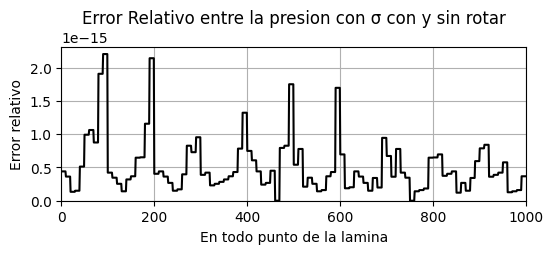

In [ ]:
# comparacion para todos los puntos
error = np.abs(p.flatten()-presion_new.flatten())/p.flatten()

# grafica error relativo
fig = plt.figure(figsize=(6,2))
plt.title('Error Relativo entre la presion con σ con y sin rotar')
plt.plot(range(len(error)), error, 'k')
plt.xlabel('En todo punto de la lamina')
plt.ylabel('Error relativo')
plt.xlim(0,len(error))
plt.ylim(0)
plt.grid()

Este resultado muestra que la presion obtenida antes y despues de rotar $σ$ usando la matriz de vectores propios es practimante identica en todo punto de la lamina. De modo que se podria concluir que la presion es invariante ante rotaciones (a traves del metodo de autovectores) sobre el tensor de esfuerzos $σ$, hecho que se podria esperar teoricamente, debido a que la presion esta definida mediante la traza del tensor $σ$, y matematicamente la traza de un tensor es uno de sus invariantes; Algo similar al problema 9.6 del Lautrup desarrollado en las clases de taller, donde se mostro la invarianza de la diagonal del tensor de esfuerzos bajo su respectiva transformacion tensorial.
Por otro lado, las fluctuaciones pueden ser causadas posiblemente por el error computacional.


<p align="center">
<img src= https://i.postimg.cc/tTn1zk7d/IMG-20240515-092132.jpg width="600">
</p>


* Proof trace of tensor matrix is invariant to rotation of the axis. Recuperado de: https://math.stackexchange.com/questions/2144464/proof-trace-of-tensor-matrix-is-invariant-to-rotation-of-the-axis
<br><br>


#### **Campo de Presion 3D (con $σ$ rotado) sobre la lamina:**

Como previamente se graficaron mapas de contorno 2D del campo de presion, y el resultado anterior muestra que ambos campos de presion son escencialmente el mismo, ahora se decidió graficar en 3D la presion obtenida despues de la rotacion para dimensionalizar su efecto sobre toda la lamina. Para graficar valumenes 3D en Plotly, se hizo uso de la documentacion de Plotly Graphing libraries:

* How to make 3D Volume Plots in Python with Plotly. Recuperado de: https://plotly.com/python/3d-volume-plots/

* How to configure and style the legend in Plotly with Python. Recuperado de: https://plotly.com/python/legend/

In [ ]:
# Crea el volumen del campo de presion
campo = presion_new
volumen = go.Volume(x=Xs.flatten(), y=Ys.flatten(), z=Zs.flatten(),
                    value=campo.flatten(),
                    isomax=max(campo.flatten()),
                    isomin=np.min(campo.flatten()),
                    opacity=0.2, surface_count=17,
                    colorscale='plasma')
fig = go.Figure(volumen)

# maximos de presion
max_indxs = np.where(campo == np.max(campo))
fig.add_trace(go.Scatter3d(x=Xs[max_indxs].flatten(),
                           y=Ys[max_indxs].flatten(),
                           z=Zs[max_indxs].flatten(),
                           mode='markers', marker=dict(size=4),
                           name='Maximos', showlegend=True))

# configuracion de figura
fig.update_layout(title='Campo de Presion [Pa] sobre toda la lamina',
                  scene=dict(xaxis=dict(title='X'),
                             yaxis=dict(title='Y'),
                             zaxis=dict(title='Z')),
                  legend=dict(title="", orientation="h",
                              y=0.05, x=0, font=dict(size=15)) )

fig.show()

<br>

### **5. Traccion, Esfuerzos Normales y Esfuerzos de Sizalla**

5. Determine el valor del vector de esfuerzo normal (tracción sobre la cara, $\vec t_n = \mathbf{\sigma}\cdot\hat n$) que experimenta el bloque en cada una de sus 6 caras y el esfuerzo normal correspondiente ($\sigma_n = \vec t_n\cdot\hat n$). Haga gráficos de contorno (mapas de calor) para el valor del esfuerzo normal en cada uno de los puntos de esas caras. Comente su resultado.  Calcule también el valor del vector de esfuerzo de cizalladura en cada una de las 3 caras ($\vec\tau_n = \vec t_n - \sigma_n\hat n$) y haga mapas de campo vectorial de esos vectores en cada una de ellas. <br><br>


* **Vectores normales a las caras**

Se tomaron los $3$ vectores canonicos de $R^3$ ($\hat{e}_i$) en las direcciones principales para las 3 caras superiores (definidas donde cada coordenada es su maximo: $lx,ly,lz$), y para las caras inferiores (definidas donde cada cordenada es $0$) basta con tomar el negativo de estos vectores canonicos.

Como notacion para denotar las caras en cada direccion se usó:
> Caras superiores: $X,Y,Z$<br>
> Caras inferiores: $-X,-Y,-Z$



In [ ]:
# vectores normales
nx = np.array([1,0,0])
ny = np.array([0,1,0])
nz = np.array([0,0,1])

* **Vectores de Traccion**

Usando el tensor de esfuerzos $\sigma$ y los vectores normales definidos previamente, se calculó su producto usando el operador `@`, para obtener los vectores de traccion de las caras inferiores entonces basta con multiplicar por menos.

$$\vec t_n = \mathbf{\sigma}\cdot\hat n$$

* **Esfuerzos Normales**

haciendo producto punto de los vectores de traccion y los vectores normales se obtienen los esfuerzos normales, nuevamente se empleó `@` gracias a su versatilidad. Junto con `lambdify` para poder evaluar todos los puntos de la lamina. Note que como a $\vec t_n$ se vuelve a hacer producto los vectores normales, para el caso de las caras inferiores, el signo negativo se estaria multiplicando dos veces, resultando en positivo, para cualquiera de las caras. entonces la expresion obtenida para el esfuerzo normal es la misma para caras superiores e inferiores, con la salvedad de que se evaluan en puntos distintos.

$$\sigma_n = \vec t_n\cdot\hat n$$


In [ ]:
# vectores de traccion
tx = σ_tensor @ nx # (matriz * vector)
ty = σ_tensor @ ny
tz = σ_tensor @ nz

# esfuerzos normales (funcion escalar simbolica)
σ_nx = tx @ nx     # (vector * vector)
σ_ny = ty @ ny
σ_nz = tz @ nz

# esfuerzos normales (funcion escalar numerica)
σnx_fun = sp.lambdify((X_sim, Y_sim, Z_sim), σ_nx, 'numpy')
σny_fun = sp.lambdify((X_sim, Y_sim, Z_sim), σ_ny, 'numpy')
σnz_fun = sp.lambdify((X_sim, Y_sim, Z_sim), σ_nz, 'numpy')

#### **Campo escalar de Esfuerzos normales sobre cada cara**

Siguiendo el mismo metodo de graficacion de los puntos previos:

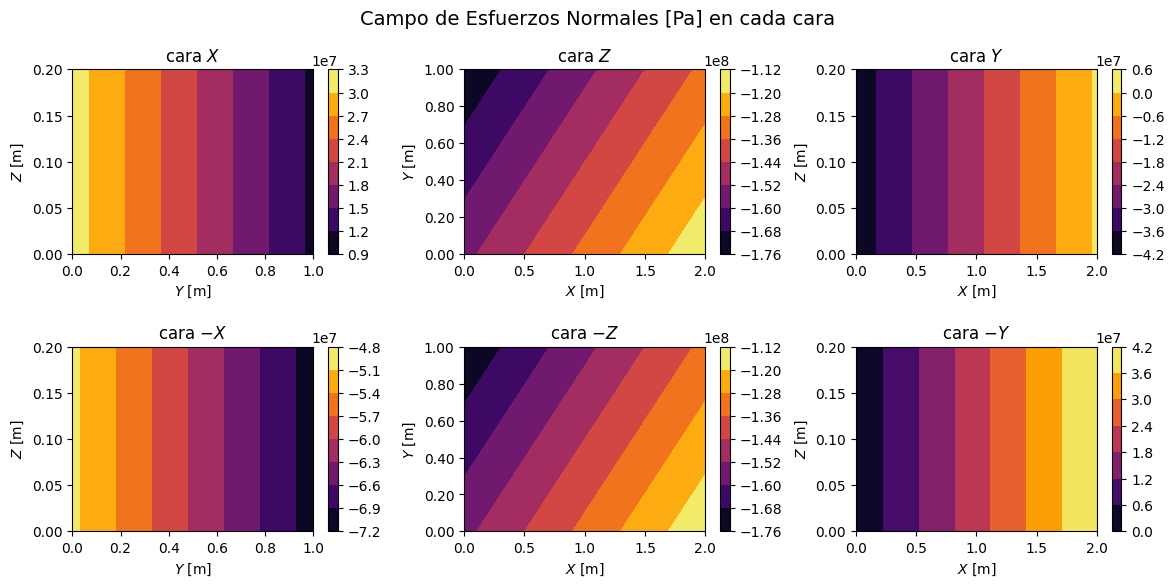

In [ ]:
# Figura
fig, ax = plt.subplots(2,3, figsize=(14,6))
fig.subplots_adjust(hspace=0.5, wspace=0.3) # separaciones
fig.suptitle('Campo de Esfuerzos Normales [Pa] en cada cara', fontsize=14)

# plano YZ (cara x)
Ys, Zs = np.meshgrid(Y, Z)
cont1 = ax[0,0].contourf(Ys, Zs, σnx_fun(lx,Ys,Zs), cmap='inferno') # superior
cont11 = ax[1,0].contourf(Ys, Zs, σnx_fun(0,Ys,Zs), cmap='inferno') # inferior
cbar1 = fig.colorbar(cont1, ax=ax[0,0])
cbar11 = fig.colorbar(cont11, ax=ax[1,0])

# plano XY (cara z)
Xs, Ys = np.meshgrid(X, Y)
cont2 = ax[0,1].contourf(Xs, Ys, σnz_fun(Xs,Ys,lz), cmap='inferno') # superior
cont22 = ax[1,1].contourf(Xs, Ys, σnz_fun(Xs,Ys,0), cmap='inferno') # inferior
cbar2 = fig.colorbar(cont2, ax=ax[0,1])
cbar22 = fig.colorbar(cont22, ax=ax[1,1])

# plano XZ (cara y)
Xs, Zs = np.meshgrid(X, Z)
cont3 = ax[0,2].contourf(Xs, Zs, σny_fun(Xs,ly,Zs), cmap='inferno') # superior
cont33 = ax[1,2].contourf(Xs, Zs, σny_fun(Xs,0,Zs), cmap='inferno') # inferior
cbar3 = fig.colorbar(cont3, ax=ax[0,2])
cbar33 = fig.colorbar(cont33, ax=ax[1,2])

# Configuraciones de figura
caraa = [['X','Z','Y'],['-X','-Z','-Y']] # cada cara
lad = [['Y','Z'], ['X','Y'], ['X','Z']] # cada label
for i in range(3):
  for j in range(2):
    ax[j,i].set_title(f'cara ${caraa[j][i]}$ ')
    ax[j,i].set_xlabel(f'${lad[i][0]}$ [m]')
    ax[j,i].set_ylabel(f'${lad[i][1]}$ [m]')
    ax[j,i].xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
    ax[j,i].yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
plt.show()

Note que, a pesar de que las caras inferiores se definen con el negativo de los vectores canonicos, siguen la misma expresion y tendencia encontrada para las caras superiores (el signo se multiplica dos veces y por eso quedan con la misma expresion), con la diferencia de que viendo las barras de color, los valores particulares de los esfuerzos normales son distintos, debido a que las caras se evaluan en puntos distintos del espacio. A exepcion de la caras de las direcciones en $Z$, las cuales si permanecen igual debido a la no dependecia de esta componente.


* **Vectores de Esfuerzo de Sizalladura**


$$\vec\tau_n = \vec t_n - \sigma_n\hat n$$

Se calcularon para las 3 caras superiores, usando los resultados de los vectores de traccion y los esfuerzos normales, y se pasaron todas las componentes de los vectores de esfuerzo de sizalladura con lambdify a funciones numericas.

In [ ]:
# vectores esfuerzo de sizalladura (componentes simbolics)
τx = tx - σ_nx * nx   # (vector - escalar * vector)
τy = ty - σ_ny * ny
τz = tz - σ_nz * nz

# vectores esfuerzo de sizalladura (componentes numericas)
τx_fun = [sp.lambdify((X_sim, Y_sim, Z_sim),τxi, 'numpy') for τxi in τx]
τy_fun = [sp.lambdify((X_sim, Y_sim, Z_sim),τyi, 'numpy') for τyi in τy]
τz_fun = [sp.lambdify((X_sim, Y_sim, Z_sim),τzi, 'numpy') for τzi in τz]

In [ ]:
# expresiones de los vectores esfuerzo de sizalladura
τx, τy, τz

(array([0, 25939849.6240602, 15563909.7744361*X - 51879699.2481203],
       dtype=object),
 array([25939849.6240602, 0, 114135338.345865], dtype=object),
 array([15563909.7744361*X - 51879699.2481203, 114135338.345865, 0],
       dtype=object))

Note que:
* $τ_x$ en direccion $e_x$ solo depende de $X$ en la componente $Z$
* $τ_y$ es constante en toda direccion
* $τ_z$ en direccion $e_x$ solo depende de $X$ en su componente $X$

#### **Campo vectorial de Esfuerzos de Sizalladura**

Con el mismo metodo de graficacion de puntos previos:

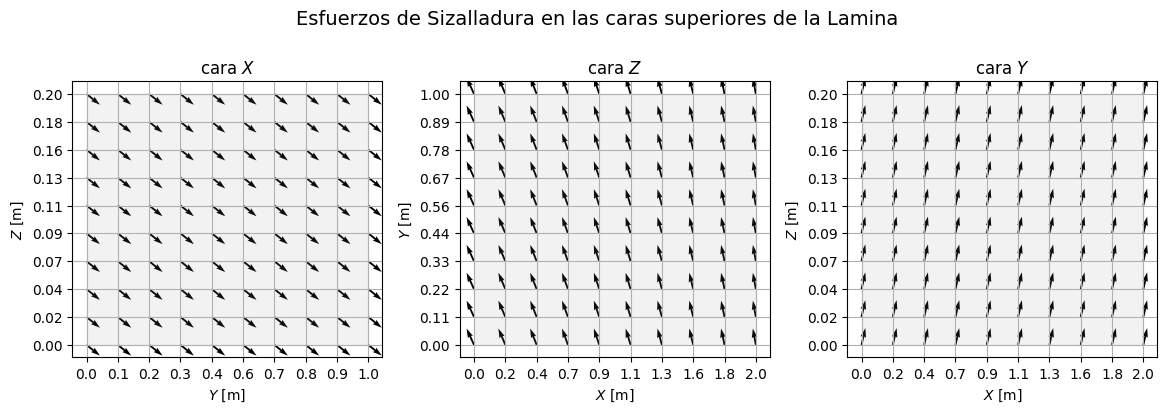

In [ ]:
# Figura
fig, ax = plt.subplots(1,3, figsize=(14,4))
fig.subplots_adjust(top=0.8, wspace=0.25) # ajuste de separacion
fig.suptitle('Esfuerzos de Sizalladura en las caras superiores de la Lamina',
             fontsize=14)

# plano YZ (cara x)
Ys, Zs = np.meshgrid(Y, Z)
ax[0].quiver(Ys, Zs,
             τx_fun[1](lx, Ys, Zs),  # componente y
             τx_fun[2](lx, Ys, Zs))  # componente z

# plano XY (cara z)
Xs, Ys = np.meshgrid(X, Y)
ax[1].quiver(Xs, Ys,
             τz_fun[0](Xs, Ys, lz), # componente x
             τz_fun[1](Xs, Ys, lz)) # componente y

# plano XZ (cara y)
Xs, Zs = np.meshgrid(X, Z)
ax[2].quiver(Xs, Zs,
             τy_fun[0](Xs, ly, Zs),  # componente x
             τy_fun[2](Xs, ly, Zs))  # componente z


# Configuraciones de figura
caraa = ['X','Z','Y'] # caras de cada plano
labels = ['YZ','XY','XZ']
lados = [[ly,lz],[lx,ly],[lx,lz]] # lados de la lamina
ticks = [[Y, Z],[X, Y],[X, Z]] # ticks asociados a cada grafica
for i in range(3):
  ax[i].set_title(f'cara ${caraa[i]}$')
  ax[i].fill_between([0,lados[i][0]],lados[i][1], color='gray', alpha=0.1)
  ax[i].xaxis.set_major_formatter(StrMethodFormatter('{x:.1f}'))
  ax[i].yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
  ax[i].set_xlabel(f'${labels[i][0]}$ [m]')
  ax[i].set_ylabel(f'${labels[i][1]}$ [m]')
  ax[i].set_xticks(ticks[i][0])
  ax[i].set_yticks(ticks[i][1])
  ax[i].grid()
plt.show()

Las magnitudes de los vectores se encuentran escaladas automaticamente, pues sus valores son muy grandes, debido a que el valor del modulo de Young se escribió en pascales.

#### **Campo vectorial de sizalla 3D**

Como las magnitudes son tan grandes, pues se trabajó con un modulo de young en Pascales (del orden de $10^9$ Pa, unidades del S.I.), en este caso se tuvo que usar un tamaño de referencia de los conos del orden de $1e7$ por motivos de visualizacion

In [ ]:
# Crear la figura
fig = go.Figure()

# plano XY (cara Z)
Xs1, Ys1 = np.meshgrid(X, Y)
Zs1 = np.full_like(Xs1, lz)
txs1 = np.full_like(Xs1, τz_fun[0](Xs1,Ys1,Zs1))
tys1 = np.full_like(Xs1, τz_fun[1](Xs1,Ys1,Zs1))
tzs1 = np.full_like(Xs1, τz_fun[2](Xs1,Ys1,Zs1))
fig.add_trace(go.Cone(x=Xs1.flatten(), y=Ys1.flatten(), z=Zs1.flatten(),
                      u=txs1.flatten(), v=tys1.flatten(), w=tzs1.flatten(),
                      anchor="tail",sizemode="absolute",colorscale='viridis',
                      sizeref=9e7, showscale=True,
                      colorbar=dict(title='cara Z', len=0.5, y=0.75, x=0,
                                    xanchor='left', yanchor='top')))

# plano XZ (cara Y)
Xs2, Zs2 = np.meshgrid(X, Z)
Ys2 = np.full_like(Xs2, ly)
txs2 = np.full_like(Xs1, τy_fun[0](Xs2,Ys2,Zs2))
tys2 = np.full_like(Xs1, τy_fun[1](Xs2,Ys2,Zs2))
tzs2 = np.full_like(Xs1, τy_fun[2](Xs2,Ys2,Zs2))
fig.add_trace(go.Cone(x=Xs2.flatten(), y=Ys2.flatten(), z=Zs2.flatten(),
                      u=txs2.flatten(), v=tys2.flatten(), w=tzs2.flatten(),
                      anchor="tail",sizemode="absolute",colorscale='Portland',
                      sizeref=9e7, showscale=True,
                      colorbar=dict(title='cara Y', len=0.5, y=0.75, x=0.9,
                                    xanchor='left', yanchor='top')))

# plano YZ (cara X)
Ys3, Zs3 = np.meshgrid(Y, Z)
Xs3 = np.full_like(Ys3, lx)
txs3 = np.full_like(Xs1,τx_fun[0](Xs3,Ys3,Zs3))
tys3 = np.full_like(Xs1,τx_fun[1](Xs3,Ys3,Zs3))
tzs3 = np.full_like(Xs1,τx_fun[2](Xs3,Ys3,Zs3))
fig.add_trace(go.Cone(x=Xs3.flatten(), y=Ys3.flatten(), z=Zs3.flatten(),
                      u=txs3.flatten(), v=tys3.flatten(), w=tzs3.flatten(),
                      anchor="tail",sizemode="absolute",colorscale='Electric',
                      sizeref=3e7, showscale=True,
                      colorbar=dict(title='cara X', len=0.5, y=0.75, x=0.9,
                                    xanchor='left', yanchor='bottom')))

# lamina
for ar in arista:
    x_3d, y_3d, z_3d = zip(vertice[ar[0]], vertice[ar[1]])
    fig.add_trace(go.Scatter3d(x=x_3d, y=y_3d, z=z_3d,
                               mode='lines', showlegend=False,
                               line=dict(color='gray',width=4)))

# Configurar figura
fig.update_layout(title='Campo de Sizalladura en caras superiores',
                  scene=dict(xaxis_title='X', yaxis_title='Y',zaxis_title='Z'),
                  margin=dict(l=0, r=0, b=0, t=40))
fig.show()

* De `chat-gpt` se extrajo la funcion `np.full_like(object, value)` la cual crea un array de la misma dimension del objeto `object` rellenando todas sus componentes con el valor `value`

<br><br>

___

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráficos de cada punto.

- Datos mínimos:
  - Los números solicitados en cada punto.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.